# Linear Algebra Python Exam Exercises — Completed Solutions

Completed Python solutions extracted from the provided past exam PDFs. The code style follows the provided NumPy/SciPy cheatsheet where applicable.

# Setup

In [86]:
import numpy as np
from scipy import linalg as la
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)

# FS 2022

## Exercise 7 — Partial sum for \(\ln 2\)

In [87]:
# ln(2) = sum_{k=1}^{infinity} (-1)^(k-1) / k

k = np.arange(1, 21)
partial_sum = np.sum((-1)**(k - 1) / k)
exact_value = np.log(2)

signed_deviation_percent = (partial_sum - exact_value) / exact_value * 100
absolute_deviation_percent = abs(signed_deviation_percent)

print("Partial sum with 20 terms:", partial_sum)
print("Exact value ln(2):", exact_value)
print("Signed deviation in percent:", signed_deviation_percent)
print("Absolute deviation in percent:", absolute_deviation_percent)

Partial sum with 20 terms: 0.6687714031754279
Exact value ln(2): 0.6931471805599453
Signed deviation in percent: -3.516681315045653
Absolute deviation in percent: 3.516681315045653


## Exercise 8 — Tank-flow linear system

In [88]:
# Unknowns are f1, f2, f3, f4, f5.
# Equilibrium equations:
# A: f1 + f2 + f3 = 20
# B: f1 - f4 = 10
# C: f2 + f4 - f5 = 0
# D: f3 + f5 = 10

A = np.array([
    [1, 1, 1,  0,  0],
    [1, 0, 0, -1,  0],
    [0, 1, 0,  1, -1],
    [0, 0, 1,  0,  1]
], dtype=float)

b = np.array([[20], [10], [0], [10]], dtype=float)

rkA = np.linalg.matrix_rank(A)
rkAb = np.linalg.matrix_rank(np.hstack([A, b]))
number_unknowns = A.shape[1]

print("rank(A):", rkA)
print("rank(A|b):", rkAb)
print("number of unknowns:", number_unknowns)
print("consistent:", rkA == rkAb)
print("unique solution:", rkA == rkAb == number_unknowns)
print("additional independent information needed:", number_unknowns - rkA)

# General solution with parameters s = f4 and t = f5:
x0 = np.array([[10], [0], [10], [0], [0]], dtype=float)
v_s = np.array([[1], [-1], [0], [1], [0]], dtype=float)
v_t = np.array([[0], [1], [-1], [0], [1]], dtype=float)

print("\nGeneral solution:")
print("[f1, f2, f3, f4, f5]^T =")
print(x0)
print("+ s *")
print(v_s)
print("+ t *")
print(v_t)

# Check the solution form for example parameters s = 2 and t = 6.
s = 2
t = 6
x = x0 + s * v_s + t * v_t
print("\nCheck A@x for s=2, t=6:")
print(A @ x)

rank(A): 3
rank(A|b): 3
number of unknowns: 5
consistent: True
unique solution: False
additional independent information needed: 2

General solution:
[f1, f2, f3, f4, f5]^T =
[[10.]
 [ 0.]
 [10.]
 [ 0.]
 [ 0.]]
+ s *
[[ 1.]
 [-1.]
 [ 0.]
 [ 1.]
 [ 0.]]
+ t *
[[ 0.]
 [ 1.]
 [-1.]
 [ 0.]
 [ 1.]]

Check A@x for s=2, t=6:
[[20.]
 [10.]
 [ 0.]
 [10.]]


# HS 2022

## Exercise 7 — Catalan constant partial sum

In [89]:
# G = sum_{n=0}^{infinity} (-1)^n / (2n + 1)^2

n = np.arange(0, 20)
partial_sum = np.sum((-1)**n / (2*n + 1)**2)

print("Partial sum with 20 terms:", partial_sum)

Partial sum with 20 terms: 0.9156536770949603


## Exercise 8 — Snow-depth regression

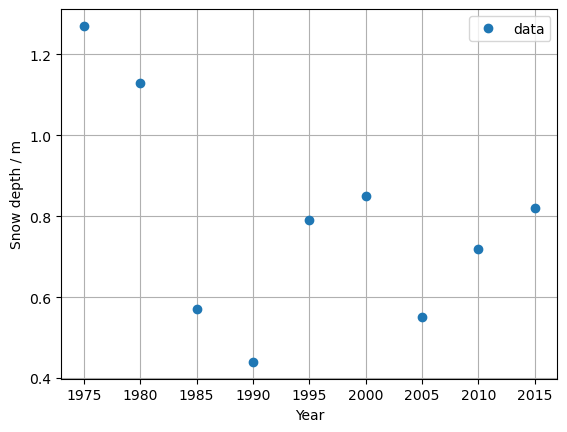

a0: 18.482333333333326
a1: -0.008866666666666662


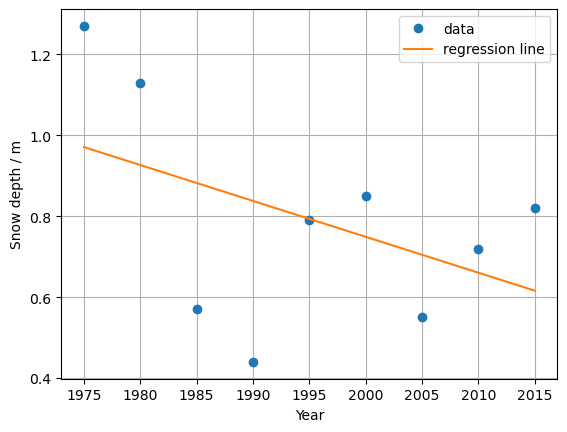

Model reaches y = 0 in year: 2084.4736842105267
Earliest full year with no January snow according to the model: 2085


In [90]:
x = np.array([[1975], [1980], [1985], [1990], [1995], [2000], [2005], [2010], [2015]], dtype=float)
y = np.array([[1.27], [1.13], [0.57], [0.44], [0.79], [0.85], [0.55], [0.72], [0.82]], dtype=float)

plt.figure()
plt.plot(x, y, "o", label="data")
plt.xlabel("Year")
plt.ylabel("Snow depth / m")
plt.grid(True)
plt.legend()
plt.show()

# Regression line y = a0 + a1*x.
M = np.hstack([np.ones(x.shape), x])
a = la.lstsq(M, y)[0]
a0 = a[0, 0]
a1 = a[1, 0]

print("a0:", a0)
print("a1:", a1)

plt.figure()
plt.plot(x, y, "o", label="data")
plt.plot(x, M @ a, label="regression line")
plt.xlabel("Year")
plt.ylabel("Snow depth / m")
plt.grid(True)
plt.legend()
plt.show()

year_no_snow = -a0 / a1
earliest_year = int(np.ceil(year_no_snow))

print("Model reaches y = 0 in year:", year_no_snow)
print("Earliest full year with no January snow according to the model:", earliest_year)

# FS 2023

## Exercise 7 — Greenhouse-gas emissions of diets

In [91]:
# E is in kg CO2-equivalents per kg food.
# D is in g food per day.
# Therefore C = D @ E.T / 1000.

food_groups = [
    "Grains", "Vegetables", "Potatoes", "Fruits", "Dairy", "Meat",
    "Fish", "Legumes", "Fat", "Eggs", "Sugar"
]

diets = ["Current", "EAT", "Vegan"]

E = np.array([[2.28, 0.81, 0.89, 0.85, 13.51, 40.34, 20.25, 1.40, 5.29, 4.67, 2.51]], dtype=float)
D = np.array([
    [279, 257, 129, 228, 818, 181, 44,  20, 70, 30, 128],
    [232, 300,  50, 200, 250,  43, 28, 125, 51, 13,  31],
    [232, 300,  50, 200,   0,   0,  0, 213, 51,  0,  31]
], dtype=float)

C = D @ E.T / 1000

print("C = D @ E.T / 1000")
for diet, value in zip(diets, C[:, 0]):
    print(diet + ":", value, "kg CO2-equivalents per day")

C = D @ E.T / 1000
Current: 21.256300000000003 kg CO2-equivalents per day
EAT: 7.248889999999999 kg CO2-equivalents per day
Vegan: 1.63226 kg CO2-equivalents per day


## Exercise 8 — Linear system solution set

In [92]:
# Unknown vector is [x, y, z, w]^T.

A = np.array([
    [ 2, -1,  0,  3],
    [ 0, -3,  5, -7],
    [ 6, -5,  3,  0],
    [-2,  0,  2, -1]
], dtype=float)

b = np.array([[7], [8], [21], [1]], dtype=float)

rkA = np.linalg.matrix_rank(A)
rkAb = np.linalg.matrix_rank(np.hstack([A, b]))

print("rank(A):", rkA)
print("rank(A|b):", rkAb)
print("consistent:", rkA == rkAb)
print("unique solution:", rkA == rkAb == A.shape[1])

# Particular solution and kernel using the cheatsheet method.
x_lstsq = la.lstsq(A, b)[0]
n = la.null_space(A)

# Scale the kernel vector so that the w-component is 1.
n = n / n[3, 0]

# Shift the least-squares particular solution to the cleaner particular solution with w = 0.
x_particular = x_lstsq - x_lstsq[3, 0] * n

print("\nGeneral solution rounded to one decimal:")
print("particular solution with w=0:")
print(np.round(x_particular, 1))
print("direction vector:")
print(np.round(n, 1))
print("\n[x, y, z, w]^T = particular + lambda * direction")

# Check.
lam = 2
x_check = x_particular + lam * n
print("\nCheck A@x for lambda=2:")
print(A @ x_check)

rank(A): 3
rank(A|b): 3
consistent: True
unique solution: False

General solution rounded to one decimal:
particular solution with w=0:
[[15.5]
 [24. ]
 [16. ]
 [ 0. ]]
direction vector:
[[-13.5]
 [-24. ]
 [-13. ]
 [  1. ]]

[x, y, z, w]^T = particular + lambda * direction

Check A@x for lambda=2:
[[ 7.]
 [ 8.]
 [21.]
 [ 1.]]


# HS 2023

## Exercise 7 — Sequences

In [93]:
# (a) Arithmetic sequence: 30, 23, 16, ..., -705.
sequence_a = np.arange(30, -706, -7)

# (b) Sequence: -3/2, 3/2^2, -3/2^3, 3/2^4, ..., 3/2^20.
n = np.arange(1, 21)
sequence_b = (-1)**n * 3 / 2**n

print("Sequence (a):")
print(sequence_a)
print("Number of elements in (a):", sequence_a.size)

print("\nSequence (b):")
print(sequence_b)
print("Number of elements in (b):", sequence_b.size)

Sequence (a):
[  30   23   16    9    2   -5  -12  -19  -26  -33  -40  -47  -54  -61
  -68  -75  -82  -89  -96 -103 -110 -117 -124 -131 -138 -145 -152 -159
 -166 -173 -180 -187 -194 -201 -208 -215 -222 -229 -236 -243 -250 -257
 -264 -271 -278 -285 -292 -299 -306 -313 -320 -327 -334 -341 -348 -355
 -362 -369 -376 -383 -390 -397 -404 -411 -418 -425 -432 -439 -446 -453
 -460 -467 -474 -481 -488 -495 -502 -509 -516 -523 -530 -537 -544 -551
 -558 -565 -572 -579 -586 -593 -600 -607 -614 -621 -628 -635 -642 -649
 -656 -663 -670 -677 -684 -691 -698 -705]
Number of elements in (a): 106

Sequence (b):
[-1.5     0.75   -0.375   0.1875 -0.0938  0.0469 -0.0234  0.0117 -0.0059
  0.0029 -0.0015  0.0007 -0.0004  0.0002 -0.0001  0.     -0.      0.
 -0.      0.    ]
Number of elements in (b): 20


## Exercise 8 — Photovoltaic energy-yield regression

In [94]:
x = np.array([[2013], [2014], [2015], [2016], [2017], [2018], [2019], [2020], [2021], [2022]], dtype=float)
y = np.array([[0.5], [0.8], [1.1], [1.3], [1.7], [2.0], [2.2], [2.6], [2.9], [3.9]], dtype=float)

M = np.hstack([np.ones(x.shape), x])
a = la.lstsq(M, y)[0]
a0 = a[0, 0]
a1 = a[1, 0]

print("Regression using all data")
print("a0:", a0)
print("a1:", a1)

target = 24
year_target = (target - a0) / a1
earliest_year = int(np.ceil(year_target))

print("Predicted year for 24 TWh:", year_target)
print("Earliest full year:", earliest_year)

# Repeat using only values from 2018 onward.
mask = x[:, 0] >= 2018
x_since_2018 = x[mask]
y_since_2018 = y[mask]

M_since_2018 = np.hstack([np.ones(x_since_2018.shape), x_since_2018])
a_since_2018 = la.lstsq(M_since_2018, y_since_2018)[0]
a0_since_2018 = a_since_2018[0, 0]
a1_since_2018 = a_since_2018[1, 0]

year_target_since_2018 = (target - a0_since_2018) / a1_since_2018
earliest_year_since_2018 = int(np.ceil(year_target_since_2018))

print("\nRegression using only data since 2018")
print("a0:", a0_since_2018)
print("a1:", a1_since_2018)
print("Predicted year for 24 TWh:", year_target_since_2018)
print("Earliest full year:", earliest_year_since_2018)
print("Change in predicted year:", earliest_year_since_2018 - earliest_year)

Regression using all data
a0: -680.3818181817015
a1: 0.33818181818176035
Predicted year for 24 TWh: 2082.8494623656024
Earliest full year: 2083

Regression using only data since 2018
a0: -906.2799999998465
a1: 0.449999999999924
Predicted year for 24 TWh: 2067.288888888897
Earliest full year: 2068
Change in predicted year: -15


# FS 2024

## Exercise 7 — Eternal annuity

In [95]:
a = 10000
p = 0.025

t = np.arange(1, 21)
K20 = np.sum(a / (1 + p)**t)
K_eternal = a / p

deviation_percent = (K20 - K_eternal) / K_eternal * 100
absolute_deviation_percent = abs(deviation_percent)

print("K20:", K20)
print("K eternal:", K_eternal)
print("Signed deviation in percent:", deviation_percent)
print("Absolute deviation in percent:", absolute_deviation_percent)

K20: 155891.62285646822
K eternal: 400000.0
Signed deviation in percent: -61.027094285882946
Absolute deviation in percent: 61.027094285882946


## Exercise 8 — Paint-delivery multipliers

In [96]:
# Unknowns are m_A, m_B, m_C, m_D.
# Each row corresponds to one quarter. Each column corresponds to one painter.

A = np.array([
    [100,  50, 500,  75],
    [300, 200, 200, 250],
    [100, 400,  60, 250],
    [100, 100, 100, 100]
], dtype=float)

b = np.array([[1000], [1000], [1000], [1000]], dtype=float)

rkA = np.linalg.matrix_rank(A)
rkAb = np.linalg.matrix_rank(np.hstack([A, b]))

print("rank(A):", rkA)
print("rank(A|b):", rkAb)
print("request exactly realizable:", rkA == rkAb)

# Since the system is inconsistent, use a least-squares solution.
m = la.lstsq(A, b)[0]

print("\nLeast-squares multipliers [m_A, m_B, m_C, m_D]^T:")
print(m)
print("\nDelivered hectoliters per quarter with these multipliers:")
print(A @ m)
print("\nDifference from requested 1000 hl per quarter:")
print(A @ m - b)

rank(A): 3
rank(A|b): 4
request exactly realizable: False

Least-squares multipliers [m_A, m_B, m_C, m_D]^T:
[[0.7835]
 [1.4846]
 [1.6032]
 [1.1341]]

Delivered hectoliters per quarter with these multipliers:
[[1039.2191]
 [1136.1135]
 [1051.9077]
 [ 500.5328]]

Difference from requested 1000 hl per quarter:
[[  39.2191]
 [ 136.1135]
 [  51.9077]
 [-499.4672]]


# HS 2025

## Exercise 7 — Battery-storage present value

In [97]:
S = 2000
r = 0.05

n10 = np.arange(1, 11)
n15 = np.arange(1, 16)

B10 = np.sum(S / (1 + r)**n10)
B15 = np.sum(S / (1 + r)**n15)

cost = 20000

print("B10:", B10)
print("B15:", B15)
print("Cost:", cost)
print("Invest in Scenario A:", B10 >= cost)
print("Invest in Scenario B:", B15 >= cost)

B10: 15443.46985836962
B15: 20759.316076361178
Cost: 20000
Invest in Scenario A: False
Invest in Scenario B: True


## Exercise 8 — Gold-price regression from CSV

         Date      End    Begin  Daily High  Daily Low
0  01.01.2025  2382.64  2382.64     2382.64    2382.64
1  02.01.2025  2424.93  2394.89     2427.47    2392.25
2  03.01.2025  2397.72  2414.25     2420.84    2395.18
3  04.01.2025  2398.61  2398.61     2398.61    2398.61
4  05.01.2025  2399.58      NaN         NaN        NaN

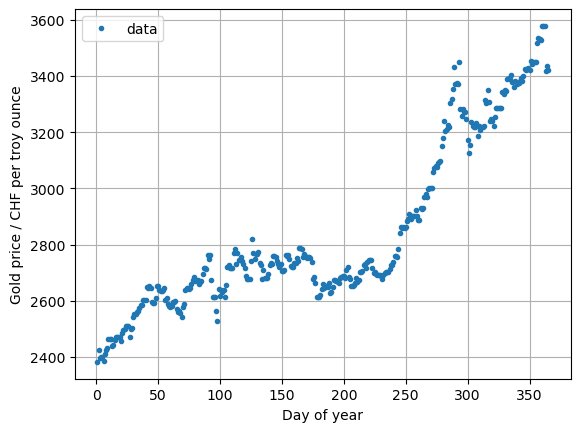

a0: 2377.052684479904
a1: 2.5519604785513152


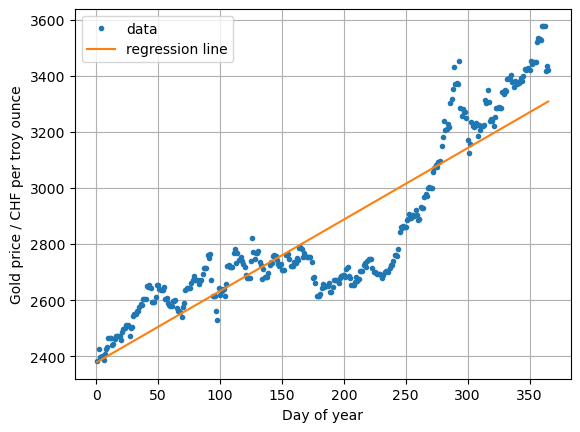

In [98]:
# The notebook expects goldprice_2025.csv in the same folder.
# The fallback paths make this cell executable in this generated environment as well.

csv_candidates = [
    Path("goldprice_2025.csv"),
    Path("python-exams/goldprice_2025.csv"),
    Path("/mnt/data/goldprice_2025.csv"),
    Path("/mnt/data/python_exams_extracted/python-exams/goldprice_2025.csv"),
]

csv_path = None
for candidate in csv_candidates:
    if candidate.exists():
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("goldprice_2025.csv was not found. Put it in the same folder as this notebook.")

df = pd.read_csv(csv_path)
print(df.head())

y = df[["End"]].to_numpy()
x = np.arange(1, y.shape[0] + 1).reshape(-1, 1)

plt.figure()
plt.plot(x, y, ".", label="data")
plt.xlabel("Day of year")
plt.ylabel("Gold price / CHF per troy ounce")
plt.grid(True)
plt.legend()
plt.show()

M = np.hstack([np.ones(x.shape), x])
a = la.lstsq(M, y)[0]
a0 = a[0, 0]
a1 = a[1, 0]

print("a0:", a0)
print("a1:", a1)

plt.figure()
plt.plot(x, y, ".", label="data")
plt.plot(x, M @ a, label="regression line")
plt.xlabel("Day of year")
plt.ylabel("Gold price / CHF per troy ounce")
plt.grid(True)
plt.legend()
plt.show()

## Exercise 8 — Gold-price regression from CSV (again)

In [99]:
# a
df = pd.read_csv("goldprice_2025.csv")
n = df.shape[0]

x = np.arange(n)
x.shape = [n,1]
y = df["End"].to_numpy()
y.shape = [n,1]

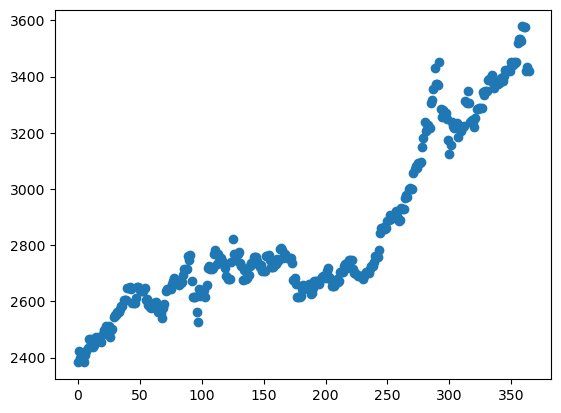

In [100]:
# b
plt.plot(x,y,"o")

In [101]:
# c
k = np.arange(2)
k.shape = [1,2]
V = x**k
a = la.lstsq(V,y)[0]
print(a)

[[2379.6046]
 [   2.552 ]]


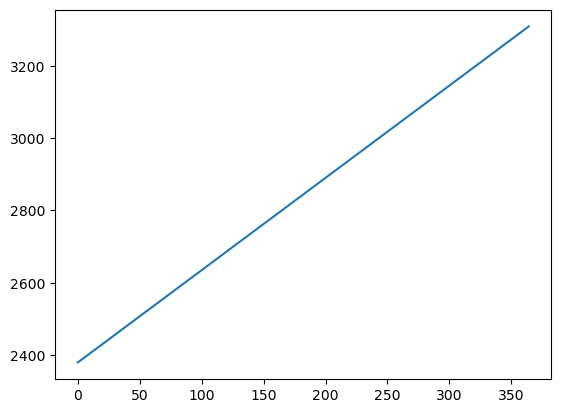

In [102]:
# d
yp = a[0,0]+a[1,0]*x
plt.plot(x,yp)

---
# ALT MEP

## Exercise 7
The circle constant $\pi$ can be calculated by the followin infinite series:
$$\pi = 3 + \frac{4}{3^3-3} - \frac{4}{5^3-5} + \frac{4}{7^3-7} - \frac{4}{9^3-9} \pm \dots$$
- With Python, calculate the partial sum of the series with 20 terms
- Is the calculated approximate value smaller or greater than $\pi$?
- What is the percentage deviation of the approximate value from $\pi$?

In [103]:
k = np.arange(19)
s = 3+sum(4*(-1)**k/((2*k+3)**3-(2*k+3)))
diff = np.pi - s
direction = "greater" if diff > 0 else "smaller"
dev = 100*abs(np.pi-s)/np.pi

print("Partial sum with 20 terms:", s)
print("Approximation is", direction, "than pi")
print(f"Percentage deviation from pi: {dev:.7f}%")

Partial sum with 20 terms: 3.1416238066678384
Approximation is smaller than pi
Percentage deviation from pi: 0.0009916%


## Question 8 — Daily nutrient demand

The table shows the amounts of some nutrients contained in 100 g of several different foods.

| Nutrient | Meat | Pasta | Vegetables |
|---|---:|---:|---:|
| Carbohydrates (g) | 0 | 32.8 | 3.7 |
| Protein (g) | 21.4 | 5.9 | 1.3 |
| Vitamin A (mg) | $5 \cdot 10^{-3}$ | 0 | 0.138 |
| Vitamin C (mg) | 0 | 0 | 30.3 |

The daily demand for these nutrients is:

- 280 g carbohydrates
- 84 g protein
- 1 mg vitamin A
- 110 mg vitamin C

**(a) (8 points)** Set up a linear system of equations $A\mathbf{x}=\mathbf{b}$ for the amounts $x_1,x_2,x_3$ of these foods, in units of 100 g, required to satisfy the daily demand.

**(b) (6 points)** Check with Python whether the system of equations is consistent and apply `scipy.la.lstsq()` to it. What is the interpretation of this result?

### Solution

Let $x_1$, $x_2$, and $x_3$ denote the amounts of meat, pasta, and vegetables, respectively, measured in units of 100 g. The four nutrient requirements give

$$
\begin{aligned}
32.8x_2+3.7x_3 &= 280,\\
21.4x_1+5.9x_2+1.3x_3 &= 84,\\
5\cdot10^{-3}x_1+0.138x_3 &= 1,\\
30.3x_3 &= 110.
\end{aligned}
$$

Therefore,

$$
A=
\begin{bmatrix}
0 & 32.8 & 3.7\\
21.4 & 5.9 & 1.3\\
5\cdot10^{-3} & 0 & 0.138\\
0 & 0 & 30.3
\end{bmatrix},\qquad
\mathbf{x}=
\begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix},\qquad
\mathbf{b}=
\begin{bmatrix}280\\84\\1\\110\end{bmatrix}.
$$

In [104]:
# x1, x2, x3 are units of 100 g of meat, pasta, and vegetables.
A = np.array([
    [0,       32.8,  3.7],
    [21.4,     5.9,  1.3],
    [5e-3,     0.0,  0.138],
    [0.0,      0.0, 30.3]
], dtype=float)

b = np.array([280, 84, 1, 110], dtype=float)

# A system is consistent exactly when rank(A) == rank([A | b]).
rank_A = np.linalg.matrix_rank(A)
rank_Ab = np.linalg.matrix_rank(np.column_stack([A, b]))
consistent = rank_A == rank_Ab

print("rank(A):", rank_A)
print("rank([A | b]):", rank_Ab)
print("consistent:", consistent)

# Since the system is inconsistent, compute the least-squares solution.
x, squared_residual, rank, singular_values = la.lstsq(A, b)
intake = A @ x
residual = intake - b

print("\nLeast-squares solution [meat, pasta, vegetables]:")
print(x)
print("\nAmounts in grams:")
print(100 * x)
print("\nNutrient intake A @ x:")
print(intake)
print("\nResidual A @ x - b:")
print(residual)
print("\nSquared residual norm:", np.sum(residual**2))

rank(A): 3
rank([A | b]): 4
consistent: False

Least-squares solution [meat, pasta, vegetables]:
[1.4641 8.1271 3.6304]

Amounts in grams:
[146.4062 812.7054 363.0437]

Nutrient intake A @ x:
[280.      84.0001   0.5083 110.0022]

Residual A @ x - b:
[-0.      0.0001 -0.4917  0.0022]

Squared residual norm: 0.2417536521075617


The ranks are $\operatorname{rank}(A)=3$ and $\operatorname{rank}([A\mid\mathbf{b}])=4$, so the system is **inconsistent**: no combination of the three foods satisfies all four demands exactly.

The least-squares result is approximately

$$
\mathbf{x}=
\begin{bmatrix}
1.4641\\8.1271\\3.6304
\end{bmatrix}.
$$

Thus the closest unweighted least-squares combination is approximately 146.4 g meat, 812.7 g pasta, and 363.0 g vegetables. It minimizes $\lVert A\mathbf{x}-\mathbf{b}\rVert_2$, but it does not satisfy every demand. In particular, it supplies only about $0.5083$ mg of vitamin A instead of $1$ mg.

> **Caution:** the equations mix grams and milligrams. Ordinary unweighted least squares treats their numerical residuals equally despite the different units. A practical nutrition model should scale or weight the nutrient equations appropriately.